Nombre: Espinoza Chiri Soledad Griselda Carrera: Ing de Sistemas
## Laboratorio 1
**Construya un programa en python que permita encontrar los mejores valores de b y w de la ecuación de la línea recta: y = b + wx, a partir de un dataset que usted seleccione, no se debe utilizar ningún framework o ecuaciones de regresiones, solo debe realizar un programa simple, con estructuras de control decisivo y repetitivo. Una vez que identifique los mejores valores de b y w, realice inferencias para 10 nuevos valores de x, explique los resultados obtenidos y el algoritmo empleado.**

# Dataset Seleccionado
Student Study Hours dataset.<br>
Este dataset representa la relación entre las horas que un estudiante dedica a estudiar y la calificación (score) que obtiene.
Donde x = Hours, variable independiente (lo que ya conocemos).<br>
y = Scores, variable dependiente (lo que queremos predecir a partir de x).

In [2]:
# Conectando / vinculando nuestro drive con la sesión de Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Cargar Dataset

In [4]:
# Cargar el dataset desde Google Drive
ruta = '/content/drive/MyDrive/SIS420/student_scores.csv'

with open(ruta, 'r') as f:
    contenido = f.readlines()

print("Total de registros (incluye encabezado):", len(contenido))
print("Encabezado:", contenido[0].strip())
print("Vista previa:")
for fila in contenido[1:6]:
    print(fila.strip())

Total de registros (incluye encabezado): 36
Encabezado: Hours,Scores
Vista previa:
2.5,21
5.1,47
3.2,27
8.5,75
3.5,30


**Separando el texto en dos listas numéricas: horas de estudio y calificaciones.**

In [6]:
horas = []
notas = []

indice = 0
for fila in contenido:
    if indice == 0:
        indice += 1
        continue
    fila = fila.strip()
    if fila == "":
        continue
    valores = fila.split(",")
    horas.append(float(valores[0]))
    notas.append(float(valores[1]))
    indice += 1

n = len(horas)
print("Cantidad de estudiantes:", n)
print("Horas (primeros 5):", horas[:5])
print("Notas (primeros 5):", notas[:5])

Cantidad de estudiantes: 35
Horas (primeros 5): [2.5, 5.1, 3.2, 8.5, 3.5]
Notas (primeros 5): [21.0, 47.0, 27.0, 75.0, 30.0]


# Búsqueda de b y w (descenso por gradiente)

In [7]:

b = 0.0
w = 0.0
alpha = 0.01
costo_anterior = float('inf')
historial_costo = []

max_iteraciones = 20000
iteracion = 0

while iteracion < max_iteraciones:
    suma_error = 0.0
    suma_error_x = 0.0
    suma_costo = 0.0

    for i in range(n):
        prediccion = b + w * horas[i]
        error = prediccion - notas[i]
        suma_error += error
        suma_error_x += error * horas[i]
        suma_costo += error ** 2

    costo = suma_costo / n
    b = b - alpha * (2 / n) * suma_error
    w = w - alpha * (2 / n) * suma_error_x
    historial_costo.append(costo)

    if abs(costo_anterior - costo) < 1e-7:
        print(f"El algoritmo convergió en la iteración {iteracion}")
        break

    costo_anterior = costo
    iteracion += 1

print(f"\nMejor b (intercepto): {round(b, 4)}")
print(f"Mejor w (pendiente):   {round(w, 4)}")
print(f"Costo final:           {round(costo, 4)}")

El algoritmo convergió en la iteración 1405

Mejor b (intercepto): 3.2573
Mejor w (pendiente):   9.6569
Costo final:           34.1135


# Inferencia con 10 nuevos valores de x

In [ ]:
horas_nuevas = [0.5, 1.8, 2.7, 3.9, 4.6, 5.8, 6.4, 7.5, 8.9, 9.5]

print("Predicciones de calificación según horas de estudio:\n")
i = 0
while i < len(horas_nuevas):
    h = horas_nuevas[i]
    nota_estimada = b + w * h
    if nota_estimada > 100:
        nota_estimada = 100.0
    print(f"Horas de estudio = {h:4.1f} -> calificación estimada = {nota_estimada:.2f}")
    i += 1

Predicciones de calificación según horas de estudio:

Horas de estudio =  0.5 -> calificación estimada = 8.09
Horas de estudio =  1.8 -> calificación estimada = 20.64
Horas de estudio =  2.7 -> calificación estimada = 29.33
Horas de estudio =  3.9 -> calificación estimada = 40.92
Horas de estudio =  4.6 -> calificación estimada = 47.68
Horas de estudio =  5.8 -> calificación estimada = 59.27
Horas de estudio =  6.4 -> calificación estimada = 65.06
Horas de estudio =  7.5 -> calificación estimada = 75.68
Horas de estudio =  8.9 -> calificación estimada = 89.20
Horas de estudio =  9.5 -> calificación estimada = 95.00


# Gráficas de resultados

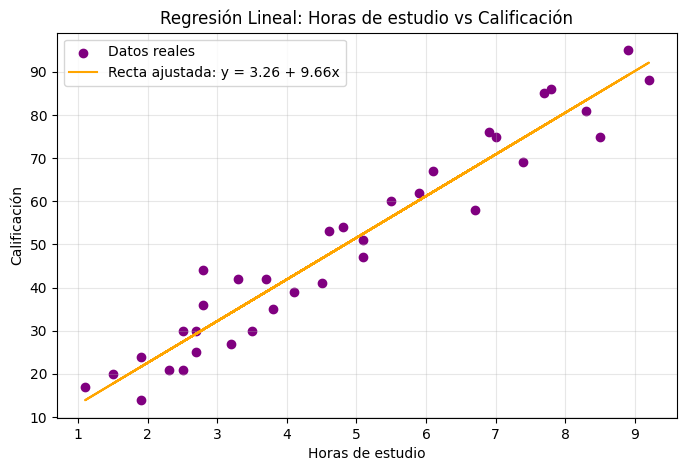

In [8]:
import matplotlib.pyplot as plt

notas_predichas = [b + w * h for h in horas]

plt.figure(figsize=(8,5))
plt.scatter(horas, notas, color='purple', label='Datos reales')
plt.plot(horas, notas_predichas, color='orange', label=f'Recta ajustada: y = {b:.2f} + {w:.2f}x')
plt.xlabel('Horas de estudio')
plt.ylabel('Calificación')
plt.title('Regresión Lineal: Horas de estudio vs Calificación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()